# Figure XX homer selection

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
import pyarrow
import fastparquet
import openpyxl
from matplotlib import markers

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

In [13]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Maria'

Plates = {'2026.07.22_homer_selection': ['Rep1_2', 'Rep3_WT','Ctrls'], '2026.08.04_homer_selection': ['Plate1_R1_R2_MOI0.1','Plate2_R3_MOI0.1_GFP_Puro', 'Plate3_R2_R3_MOI0', 'Plate4_ctrls' ]
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'Single_cell_csvs')
        yaml_path.append(base_path/i/j/'Single_cell_csvs'/'wells.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_homer'
cache_path = rd.rootdir/'output'/'Figure_XX_homer'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
1,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
2,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
3,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
4,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
5,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...
6,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...,C:\Users\Grad2024\Nextcloud\data\attune\Maria\...


In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','GFP-H','GFP-A', 'iRFP670-A','iRFP670-H', 'FSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
display(data)

,moi,cond,puro,biorep,well,population,FSC-A,GFP-A,GFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H
0,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,594052,179,113,11302,7908,158.0,146.0
1,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,639589,19736,13074,17750,13096,49.0,106.0
2,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,572142,4758,3234,2199,1766,96.0,82.0
3,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,430421,-35,66,5329,4975,-25.0,64.0
4,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,432736,3052,2316,4529,4117,154.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28495200,0.1,none,10,2,F9,Single Cells,308212,23,60,552,590,254.0,201.0
28495201,0.1,none,10,2,F9,Single Cells,271648,117,67,519,421,280.0,252.0
28495202,0.1,none,10,2,F9,Single Cells,299841,146,119,305,315,571.0,558.0
28495203,0.1,none,10,2,F9,Single Cells,243433,195,128,244,314,350.0,333.0


In [5]:
channel_list = ['mRuby2-A', 'mRuby2-H','GFP-H','GFP-A', 'iRFP670-A','iRFP670-H']
for channel in channel_list:
    data.loc[data[channel] <=0, channel] = 1

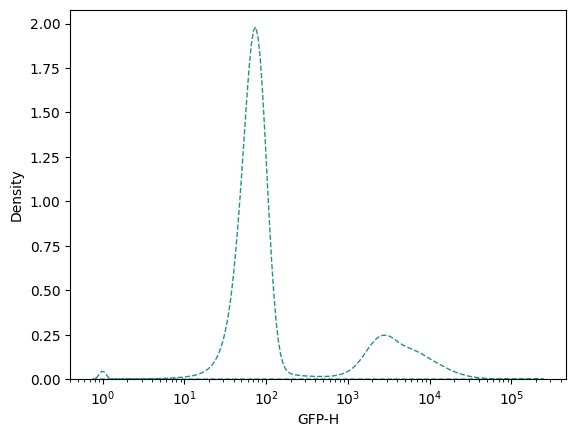

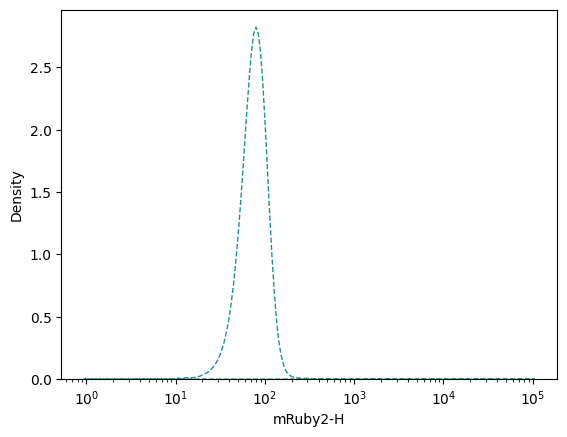

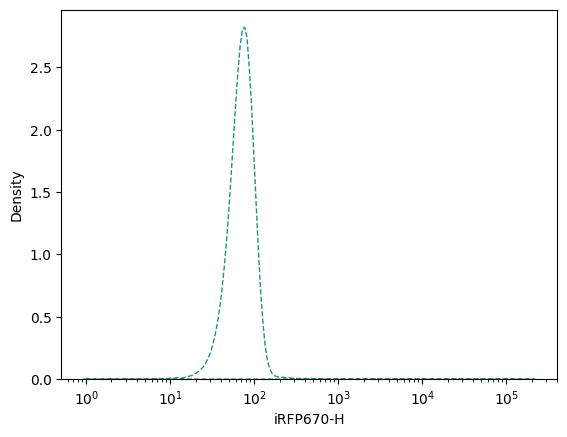

In [6]:
parameters = np.array(['GFP-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['cond'] == 'none')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='cond',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [7]:
untransduced = data[(data['moi'] == 0)& (data['cond'] != 'Puro-GFP')]
df_no_mruby = data[data['cond'] == 'none']
gfp_threshold = untransduced['GFP-A'].quantile(0.9995)
mruby_threshold = df_no_mruby['mRuby2-A'].quantile(0.9995)
display(gfp_threshold)

np.float64(286.0)

In [8]:
display(gfp_threshold)

np.float64(286.0)

In [9]:
iRFP670_H_thresh = 2.5e2
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+
group =['cond', 'puro', 'biorep', 'moi']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

In [10]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['GFP-H'] > gfp_threshold), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = ['cond', 'puro', 'biorep', 'moi']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'GFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

In [11]:
# Get total counts and percent of GFP-H+ of the infected cells
group = ['cond', 'puro', 'biorep', 'moi']
count_df_reps_control = data.groupby([*group, 'well', 'eGFP_cat'])[
    'GFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps_control = (count_df_reps_control*100/count_df_reps_control.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps_control = count_df_reps_control.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps_control = percent_df_reps_control.loc[(percent_df_reps_control['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps_control = data_eGFP_count_reps_control.loc[(data_eGFP_count_reps_control['eGFP_cat'] == 'eGFP+')]

In [12]:
display(data_eGFP_count_reps_control)

,cond,puro,biorep,moi,well,eGFP_cat,count
0,Puro-GFP,0,0,0.0,A1,eGFP+,4523
2,Puro-GFP,0,0,0.0,B1,eGFP+,4302
4,Puro-GFP,0,0,0.0,C1,eGFP+,5141
6,Puro-GFP,0,0,0.0,D1,eGFP+,5209
8,Puro-GFP,0,2,0.0,E1,eGFP+,4314
...,...,...,...,...,...,...,...
1144,wtNb(Homer),40,3,0.1,D4,eGFP+,15360
1146,wtNb(Homer),40,3,1.0,A4,eGFP+,42352
1148,wtNb(Homer),40,3,1.0,B4,eGFP+,68648
1150,wtNb(Homer),40,3,1.0,C4,eGFP+,42528


Summary stats

In [13]:
summary_dfs = []
groupby_cols = ['cond', 'puro', 'biorep', 'well', 'moi']
sc_count = data.groupby(groupby_cols).size().reset_index(name = "sc_count")
mruby_count = data.groupby(groupby_cols).apply(lambda data: sum(data['mRuby2-A'] > mruby_threshold)).reset_index(name = "mruby_count")
gfp_count = data.groupby(groupby_cols).apply(lambda data: sum(data['GFP-A'] >gfp_threshold)).reset_index(name = "gfp_count")



dfiii = sc_count.merge(mruby_count)
dfii = dfiii.merge(gfp_count)
dfii["purity"] = dfii['gfp_count'] / dfii['sc_count']*100
summary_dfs.append(dfii)

summary_df = pd.concat(summary_dfs, ignore_index=True)

In [14]:
display(summary_df)

,cond,puro,biorep,well,moi,sc_count,mruby_count,gfp_count,purity
0,Puro-GFP,0,0,A1,0.0,64229,1,5149,8.016628
1,Puro-GFP,0,0,B1,0.0,61378,5,4801,7.822021
2,Puro-GFP,0,0,C1,0.0,66851,0,5769,8.629639
3,Puro-GFP,0,0,D1,0.0,69789,0,5849,8.380977
4,Puro-GFP,0,2,E1,0.0,61890,5,4805,7.763774
...,...,...,...,...,...,...,...,...,...
572,wtNb(Homer),40,3,D4,1.0,91640,61526,72477,79.088826
573,wtNb(Homer),40,3,E4,0.0,68373,3059,22,0.032176
574,wtNb(Homer),40,3,F4,0.0,51260,2208,23,0.044869
575,wtNb(Homer),40,3,G4,0.0,58299,2935,25,0.042882


In [28]:
#universal plotting parameters
yaxis_fontsize = 14
xaxis_fontsize = 14
title_fontsize = 16
legend_title_fontsize = 14
legend_fontsize = 12
alpha_main = 0.8
alpha_biorep = 0.45
dot_size = 7
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456', 'black']

none_0 vs. none_10: ****
Puro-GFP_0 vs. Puro-GFP_40: ****
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: **
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


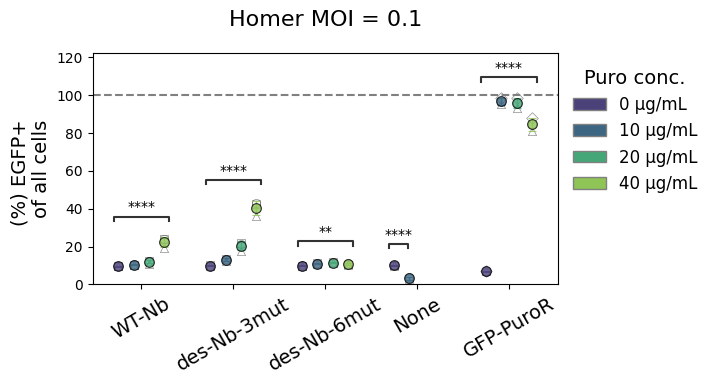

In [16]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'percent'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none",
    "Puro-GFP"
]

subset = data_eGFP_percent_reps_control[
    (data_eGFP_percent_reps_control['moi'] == 0.1) |
    (data_eGFP_percent_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(%) EGFP+ \nof all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, 
    fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
    (('Puro-GFP', 0), ('Puro-GFP', 40)),
    (('none', 0), ('none', 10))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI0.1_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

none_0 vs. none_40: ns
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


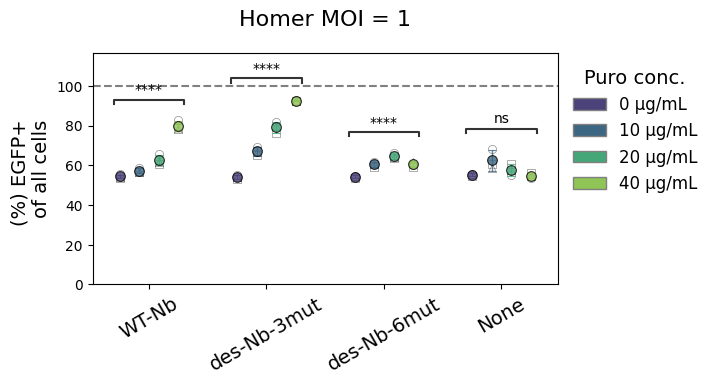

In [17]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'percent'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

subset = data_eGFP_percent_reps_control[
    (data_eGFP_percent_reps_control['moi'] == 1) 
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(%) EGFP+ \nof all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')
ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, 
    fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
    (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI1_purity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ns


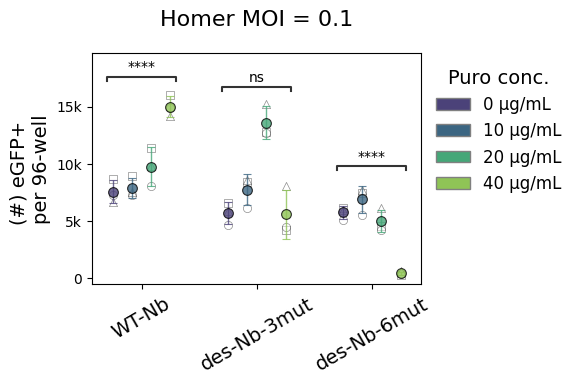

In [18]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_eGFP_count_reps_control[
    (data_eGFP_count_reps_control['moi'] == 0.1) |
    (data_eGFP_count_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)




# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


#fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI0.1_EGFP_count_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

Combined MOI 1 Homer-GFP + MOI 0.1 Puro-GFP

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: **
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: *


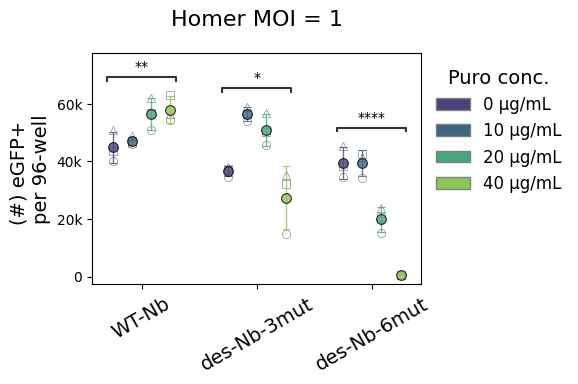

In [19]:

hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_eGFP_count_reps_control[
    (data_eGFP_count_reps_control['moi'] == 1) |
    (data_eGFP_count_reps_control['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) eGFP+ \nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)




# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer_MOI1_EGFP_count_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ns
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


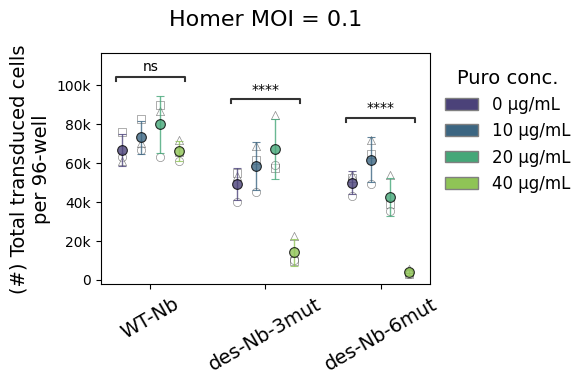

In [20]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_iRFP670_count_reps[
    (data_iRFP670_count_reps['moi'] == 0.1) |
    (data_iRFP670_count_reps['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer__MOI0.1_transduced_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
wtNb(Homer)_0 vs. wtNb(Homer)_40: ns
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****


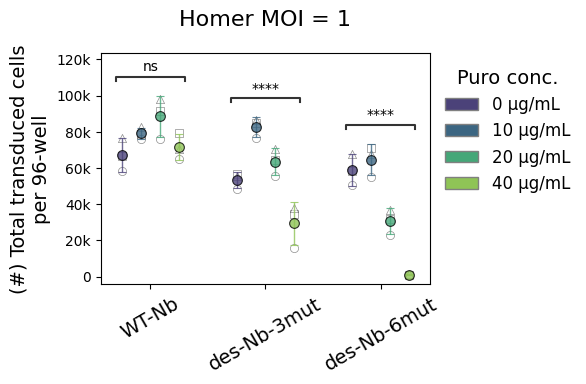

In [21]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]

# General plotting params
x = 'cond'
y = 'count'

order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut"
]

subset = data_iRFP670_count_reps[
    (data_iRFP670_count_reps['moi'] == 1) |
    (data_iRFP670_count_reps['cond'] == 'Puro-GFP')
]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(4.25,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)

# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
    (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
    (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
    (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40))
    # (('Puro-GFP', 0), ('Puro-GFP', 40)),
    # (('none', 0), ('none', 40))
]


annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()


# fig.tight_layout()

plottitle = 'Figure_XX_homer__MOI1_transduced_cells.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

In [22]:
display(data)

,moi,cond,puro,biorep,well,population,FSC-A,GFP-A,GFP-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,iRFP670_cat,eGFP_cat
0,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,594052,179,113,11302,7908,158.0,146.0,iRFP670+,eGFP-
1,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,639589,19736,13074,17750,13096,49.0,106.0,iRFP670+,eGFP+
2,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,572142,4758,3234,2199,1766,96.0,82.0,iRFP670+,eGFP+
3,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,430421,1,66,5329,4975,1.0,64.0,iRFP670+,eGFP-
4,1.0,desNb(Homer)-6mut,10,1,A10,Single Cells,432736,3052,2316,4529,4117,154.0,84.0,iRFP670+,eGFP+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28495200,0.1,none,10,2,F9,Single Cells,308212,23,60,552,590,254.0,201.0,iRFP670+,eGFP-
28495201,0.1,none,10,2,F9,Single Cells,271648,117,67,519,421,280.0,252.0,iRFP670+,eGFP-
28495202,0.1,none,10,2,F9,Single Cells,299841,146,119,305,315,571.0,558.0,iRFP670+,eGFP-
28495203,0.1,none,10,2,F9,Single Cells,243433,195,128,244,314,350.0,333.0,iRFP670+,eGFP-


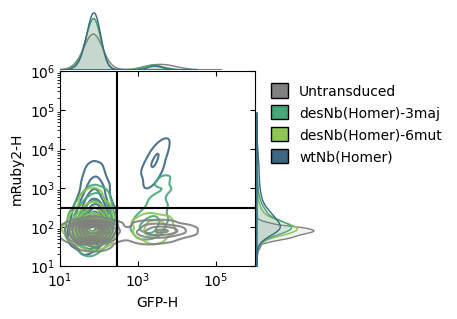

In [23]:
# General plotting params
x = "GFP-H"
y = "mRuby2-H"
hue = "cond"


hue_order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

# Conditions

palette = {'none': 'grey', 
'wtNb(Homer)':'#3C6682', 
'desNb(Homer)-3maj':'#45A778', 
'desNb(Homer)-6mut':'#8FC456'}

# Conditions
data_new = df_infected[(df_infected['GFP-H'] > 0 ) & (df_infected['mRuby2-H'] > 0) & (df_infected['moi'] == 0.1) & (df_infected['puro'] == 0)]
untransfected = data[(data['GFP-H'] > 0) & (data['mRuby2-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none') ]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=1000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)


# from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransduced'),
    Patch(facecolor='#45A778', edgecolor='black', linewidth=1,
          label='desNb(Homer)-3maj'),
    Patch(facecolor='#8FC456', edgecolor='black', linewidth=1,
          label='desNb(Homer)-6mut'),
              Patch(facecolor='#3C6682', edgecolor='black', linewidth=1,
          label='wtNb(Homer)')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(300, 0, 1, color='black')
ax_scatter.axhline(300, 0, 1, color='black')


# fig.tight_layout()  # Helps improve white spacing

plottitle = 'homer_contour_MOI0.1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

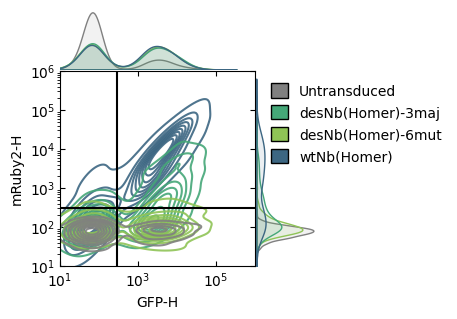

In [24]:
# General plotting params
x = "GFP-H"
y = "mRuby2-H"
hue = "cond"


hue_order = [
    "wtNb(Homer)",
    "desNb(Homer)-3maj",
    "desNb(Homer)-6mut",
    "none"
]

# Conditions

palette = {'none': 'grey', 
'wtNb(Homer)':'#3C6682', 
'desNb(Homer)-3maj':'#45A778', 
'desNb(Homer)-6mut':'#8FC456'}

# Conditions
data_new = df_infected[(df_infected['GFP-H'] > 0 ) & (df_infected['mRuby2-H'] > 0) & (df_infected['moi'] == 1) & (df_infected['puro'] == 0)]
untransfected = data[(data['GFP-H'] > 0) & (data['mRuby2-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none') ]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=1000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)


# from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransduced'),
    Patch(facecolor='#45A778', edgecolor='black', linewidth=1,
          label='desNb(Homer)-3maj'),
    Patch(facecolor='#8FC456', edgecolor='black', linewidth=1,
          label='desNb(Homer)-6mut'),
              Patch(facecolor='#3C6682', edgecolor='black', linewidth=1,
          label='wtNb(Homer)')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(300, 0, 1, color='black')
ax_scatter.axhline(300, 0, 1, color='black')


# fig.tight_layout()  # Helps improve white spacing

plottitle = 'homer_contour_MOI1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Old graphs

Just looking at Homer1-GFP MOI 1

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_33764\958156151.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

none_0 vs. none_40: t-test independent samples, P_val:1.242e-02 t=2.723e+00
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: t-test independent samples, P_val:7.554e-09 t=-9.024e+00
wtNb(Homer)_0 vs. wtNb(Homer)_40: t-test independent samples, P_val:3.721e-21 t=-3.641e+01
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: t-test independent samples, P_val:1.824e-31 t=-1.079e+02


Text(0.5, 0.98, 'Homer1 MOI 1')

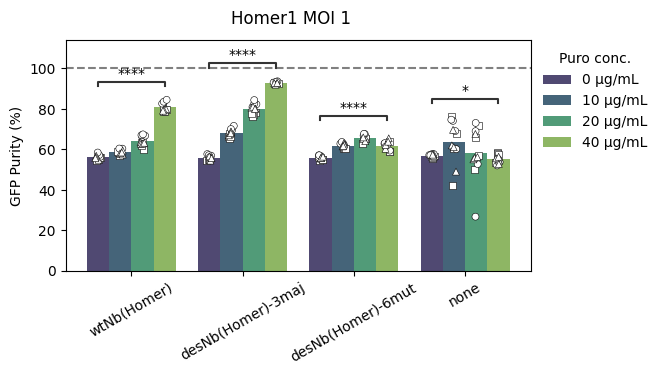

In [25]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
summary_df_01 = summary_df[summary_df['moi'] == 1]
hue = 'puro'
hue_order = [0, 10, 20, 40]
# General plotting params
x = 'cond'
y = 'purity'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none"]

summary_df_01 = summary_df[summary_df['moi'] == 1]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 0: 'D'}
# Plot
sns.barplot(
    ax=ax, data=summary_df_01,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_01[summary_df_01['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )


# Formatting
ax.yaxis.set_label_text('GFP Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

ax.tick_params(axis='x', labelrotation=30)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('none', 0), ('none', 40))
        

         ]


annotator = Annotator(
    plt.gca(),
    pairs=pairs, order = order,
    data= summary_df_01,
    x=x,
    y=y,
    hue = hue
)

annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

# Format
plt.suptitle('Homer1 MOI 1')


Just looking at MOI 0 for Homer1-GFP

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_33764\969457880.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Puro-GFP_0 vs. Puro-GFP_40: t-test independent samples, P_val:2.360e-26 t=-6.306e+01
none_0 vs. none_40: t-test independent samples, P_val:4.755e-04 t=-4.525e+00
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: t-test independent samples, P_val:6.437e-02 t=-1.952e+00
wtNb(Homer)_0 vs. wtNb(Homer)_40: t-test independent samples, P_val:1.437e-02 t=-2.658e+00
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: t-test independent samples, P_val:6.753e-03 t=-2.990e+00


Text(0.5, 0.98, 'Homer1 MOI 0')

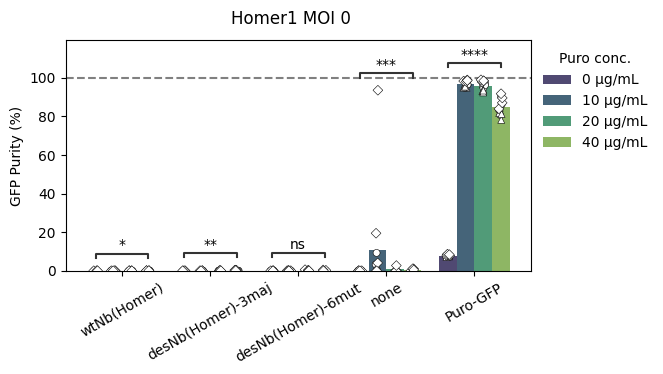

In [26]:
summary_df_0 = summary_df[summary_df['moi'] == 0]

hue = 'puro'
x = 'cond'
y = 'purity'

order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))
# Plot
sns.barplot(
    ax=ax, data=summary_df_0,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_0[summary_df_0['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('GFP Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('Puro-GFP', 0), ('Puro-GFP', 40)),
            (('none', 0), ('none', 40))
        

         ]


annotator = Annotator(
    plt.gca(),
    pairs=pairs, order = order,
    data= summary_df_0,
    x=x,
    y=y,
    hue = hue
)

annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.tick_params(axis='x', labelrotation=30)
# Format
plt.suptitle('Homer1 MOI 0')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_33764\3120731616.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Text(0.5, 0.98, 'Homer1 MOI 1')

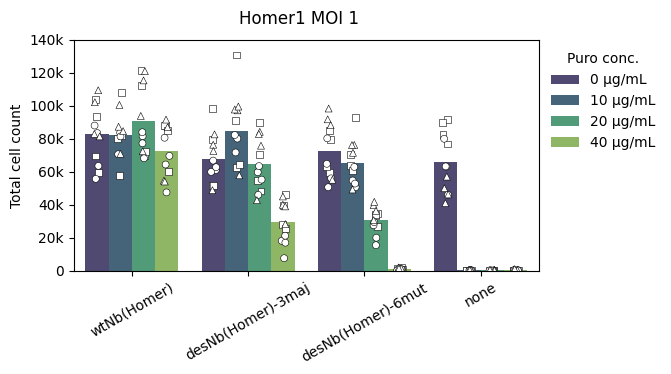

In [27]:
y = 'sc_count'

hue = 'puro'

order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))
# Plot
sns.barplot(
    ax=ax, data=summary_df_01,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_01[summary_df_01['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('Total cell count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

plt.ylim(0, 140000)
ax.tick_params(axis='x', labelrotation=30)

# Format
plt.suptitle('Homer1 MOI 1')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_33764\395251424.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Text(0.5, 0.98, 'Homer1 MOI 0')

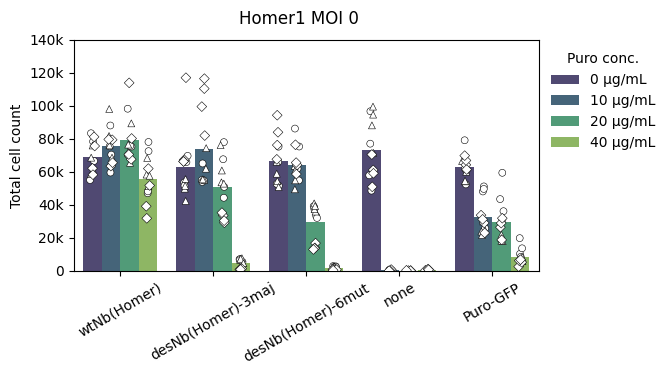

In [28]:
y = 'sc_count'

hue = 'puro'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=summary_df_0,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_0[summary_df_0['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('Total cell count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


plt.ylim(0, 140000)
ax.tick_params(axis='x', labelrotation=30)

# Format
plt.suptitle('Homer1 MOI 0')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

# ModRNA data

## MOI 1, 3 bioreps

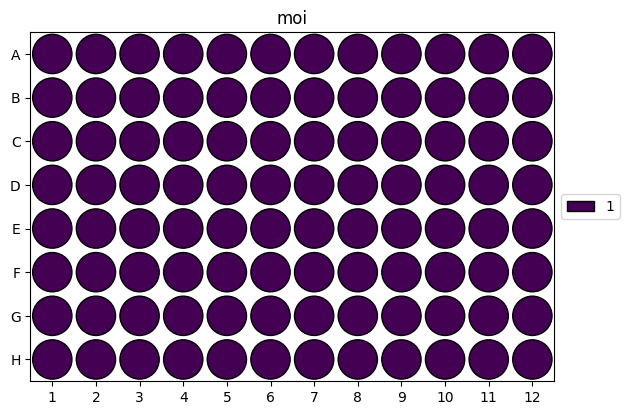

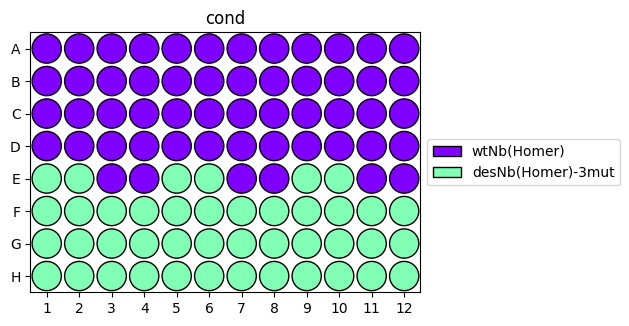

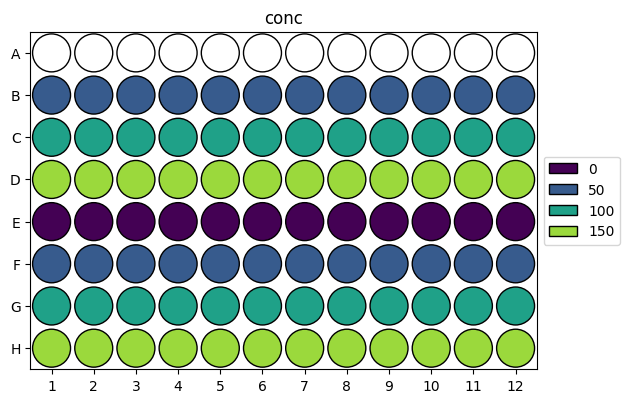

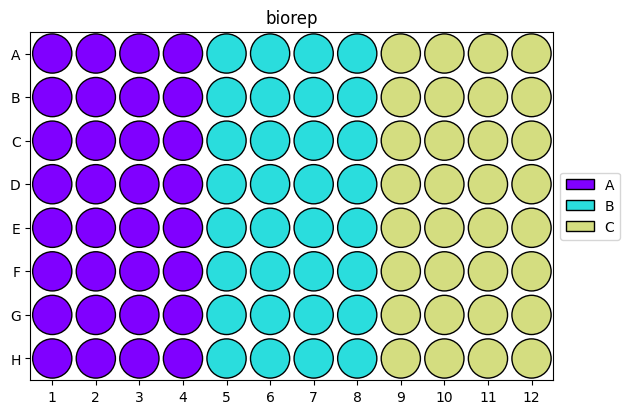

In [29]:
yaml_path_6mut_0 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'6mut_MOI0'/'Single_cell_csvs'/'wells.yaml'
yaml_path_wt_3maj_0 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'wt_3maj_MOI0'/'Single_cell_csvs'/'wells.yaml'

yaml_path_6mut_1 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'6mut_MOI1'/'Single_cell_csvs'/'wells.yaml'
yaml_path_wt_3maj_1 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'wt_3maj_MOI1'/'Single_cell_csvs'/'wells.yaml'
rd.plot.plot_well_metadata(yaml_path_wt_3maj_1)

In [30]:
data_path_wt_3maj_0 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'wt_3maj_MOI0'/'Single_cell_csvs'
data_path_6mut_0 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'6mut_MOI0'/'Single_cell_csvs'
data_path_wt_3maj_1 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'wt_3maj_MOI1'/'Single_cell_csvs'
data_path_6mut_1 = rd.datadir/'data'/'attune'/'Maria'/'2026.06.25_homer_mod_select'/'6mut_MOI1'/'Single_cell_csvs'

In [31]:
df_wt_3maj_0 = rd.flow.load_csv_with_metadata(data_path_wt_3maj_0, yaml_path_wt_3maj_0)
df_6mut_0 = rd.flow.load_csv_with_metadata(data_path_6mut_0, yaml_path_6mut_0)
df_wt_3maj_1 = rd.flow.load_csv_with_metadata(data_path_wt_3maj_1, yaml_path_wt_3maj_1)
df_6mut_1 = rd.flow.load_csv_with_metadata(data_path_6mut_1, yaml_path_6mut_1)

In [32]:
df = pd.concat([df_wt_3maj_0, df_6mut_0, df_wt_3maj_1, df_6mut_1], ignore_index=True)

In [33]:
df_log_friendly = df.loc[(df['GFP-A'] > 0) & (df['TagBFP-A'] > 0) & (df['mRuby2-A'] > 0)].copy()

In [34]:
df_log_friendly

,moi,cond,conc,biorep,well,population,FSC-A,FSC-H,FSC-W,SSC-A,...,mRuby2-A,mRuby2-H,mRuby2-W,YL3-A,YL3-H,YL3-W,YL4-A,YL4-H,YL4-W,Time
1,0,wtNb(Homer),50,C,B10,Single Cells,507028,281620,127,454206,...,5.0,69.0,0,249.0,340.0,0,423,229,0,0.008
2,0,wtNb(Homer),50,C,B10,Single Cells,568197,346939,128,435787,...,88.0,172.0,0,455.0,301.0,0,335,317,0,0.025
9,0,wtNb(Homer),50,C,B10,Single Cells,508709,343410,141,257484,...,53.0,108.0,0,396.0,555.0,0,225,177,0,0.123
10,0,wtNb(Homer),50,C,B10,Single Cells,575797,371701,143,342301,...,70.0,99.0,0,238.0,314.0,0,146,96,0,0.125
11,0,wtNb(Homer),50,C,B10,Single Cells,358111,308158,117,360206,...,113.0,107.0,0,292.0,372.0,0,148,155,0,0.142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7570370,1,<NA>,<NA>,C,H9,Single Cells,542187,315507,134,356315,...,81.0,98.0,0,94.0,203.0,0,26,83,0,22.543
7570372,1,<NA>,<NA>,C,H9,Single Cells,515003,313186,128,278119,...,31.0,73.0,0,370.0,289.0,0,-115,37,0,22.550
7570373,1,<NA>,<NA>,C,H9,Single Cells,508450,352029,124,253293,...,26.0,88.0,0,229.0,204.0,0,-14,82,0,22.550
7570375,1,<NA>,<NA>,C,H9,Single Cells,352437,267918,115,172040,...,33.0,63.0,0,375.0,306.0,0,-26,70,0,22.551


In [35]:
cond_order = ['wtNb(Homer)', 'desNb(Homer)-3mut', 'desNb(Homer)-6mut', 'mRuby-ctrl']
df_log_friendly['cond'] = pd.Categorical(
    df_log_friendly['cond'], 
    categories=cond_order, 
    ordered=True
)

In [36]:
numSamples = 10**4
small_data_moi_0 = df_log_friendly[df_log_friendly.moi == 0].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_moi_1 = df_log_friendly[df_log_friendly.moi == 1].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_all = df_log_friendly.groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)

In [37]:
small_data_all = small_data_all.sort_values('cond')

In [38]:
TagBFP_A_thresh = small_data_moi_0['TagBFP-A'].quantile(0.998)
untransfected = small_data_all[small_data_all['conc']==0]
mRuby2_A_thresh = untransfected['mRuby2-A'].quantile(0.999)

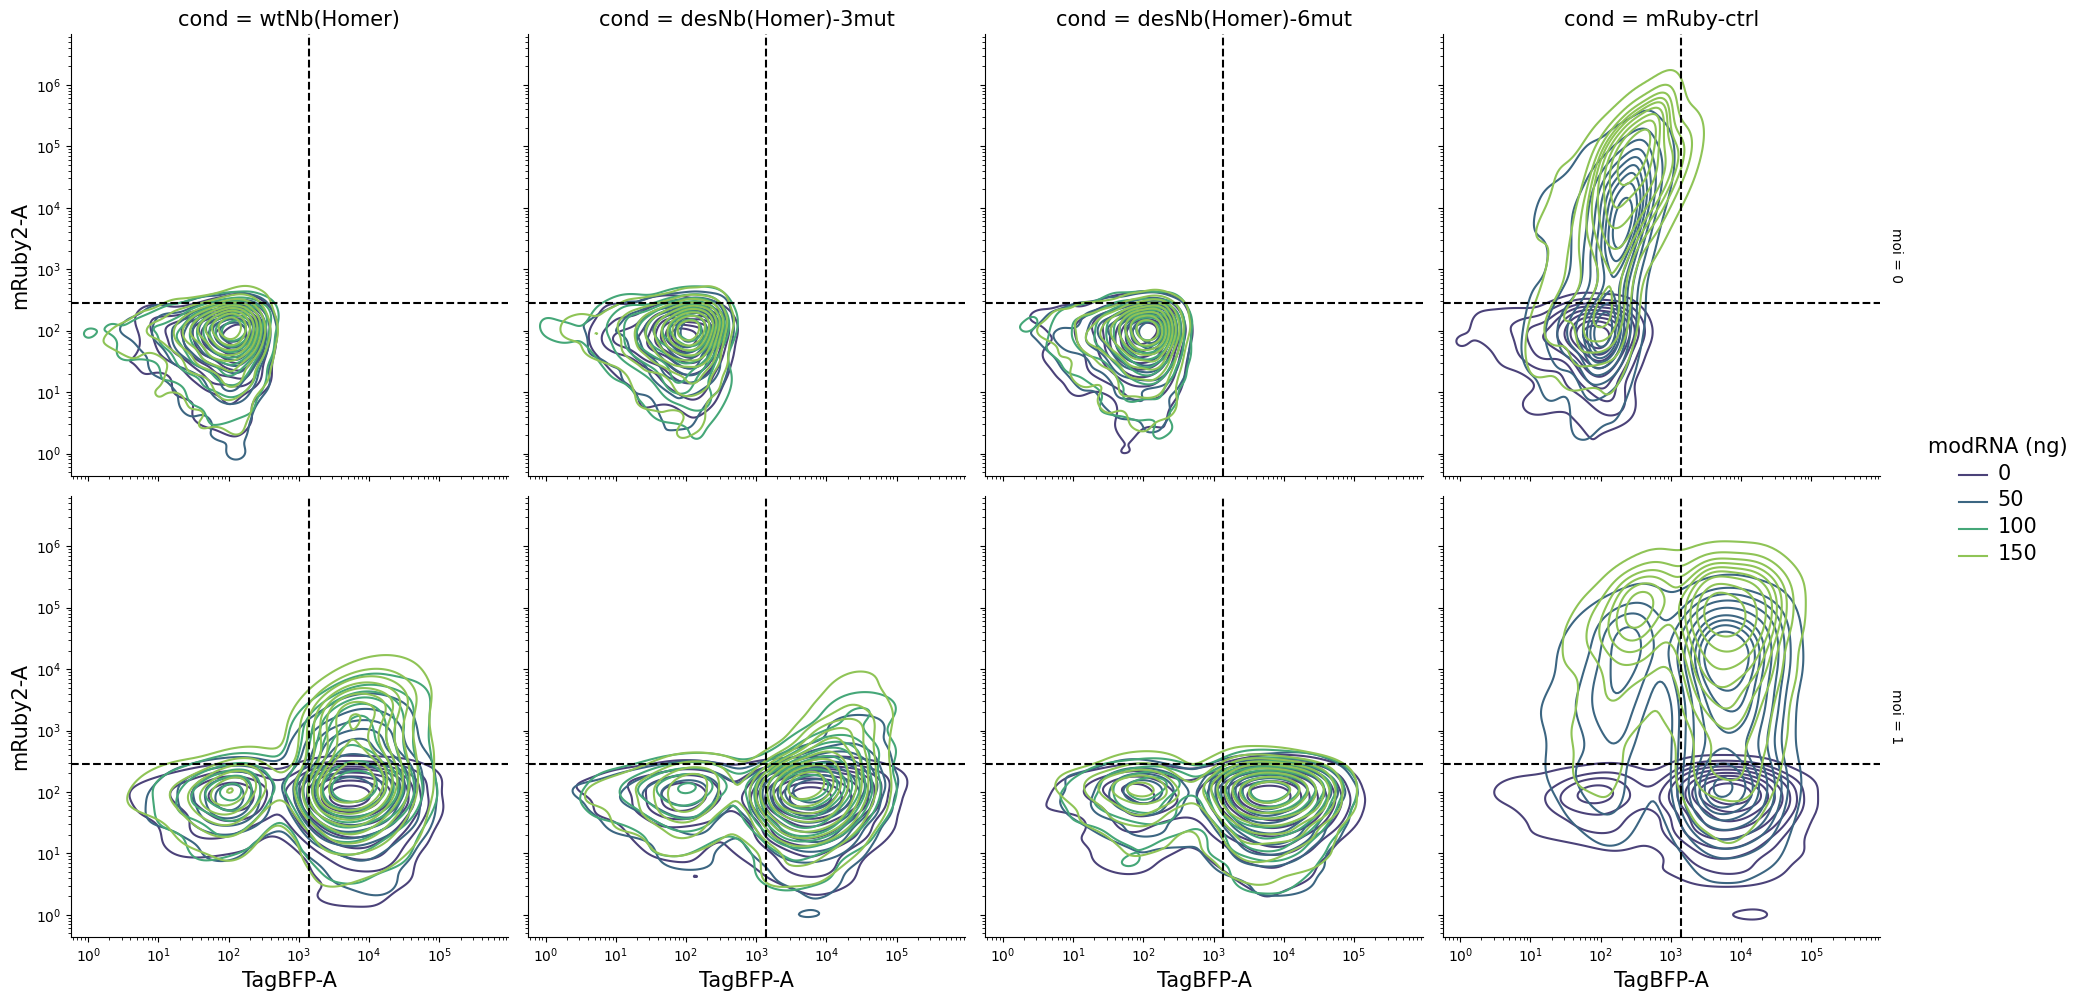

In [39]:
g = sns.displot(data = small_data_all, x = 'TagBFP-A', y = 'mRuby2-A', hue = 'conc', row = 'moi',col = 'cond', col_order=cond_order, log_scale=True, common_norm=False, kind='kde', facet_kws=dict(margin_titles=True), palette = palette)
ax_vlines = [ax.axvline(TagBFP_A_thresh, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_hlines = [ax.axhline(mRuby2_A_thresh, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_xfontsizes = [ax.set_xlabel(ax.get_xlabel(), fontsize=15) for ax in g.axes.flatten()]
ax_yfontsizes = [ax.set_ylabel(ax.get_ylabel(), fontsize=15) for ax in g.axes.flatten()]
ax_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes.flatten()]
ax_row_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes[:,0]]

# Change the legend title
g.legend.set_title("modRNA (ng)")

# Change font sizes
plt.setp(g.legend.get_texts(), fontsize=15)
g.legend.get_title().set_fontsize(15)

plottitle = 'homer_mod_contour_MOI0_1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

In [40]:
# Cat mRuby2 and TagBFP
df.loc[:, 'TagBFP_cat'] = 'TagBFP-'
df.loc[(df['TagBFP-A'] > TagBFP_A_thresh), 'TagBFP_cat'] = 'TagBFP+'
df.loc[:, 'mRuby2_cat'] = 'mRuby2-'
df.loc[(df['mRuby2-A'] > mRuby2_A_thresh), 'mRuby2_cat'] = 'mRuby2+'

# Get only mRuby2+
mRuby2_df = df.loc[df['mRuby2_cat'] == 'mRuby2+'] 

# Calculate mRuby2+ populations using these metrics
well_group = ['cond', 'moi', 'conc', 'well','biorep']
count_df = mRuby2_df.groupby([*well_group])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if none rather than dropping row
mRuby_percent_df = (count_df*100/count_df.groupby(well_group
                           ).transform('sum')).reset_index(name='percent')

mRuby_count = df.groupby([*well_group])['mRuby2-A'].apply(lambda x: sum(x > mRuby2_A_thresh)).reset_index(name = "mRuby_count")
BFP_count = df.groupby([*well_group])['TagBFP-A'].apply(lambda x: sum(x > TagBFP_A_thresh)).reset_index(name = "TagBFP_count")
double_count = df.groupby(well_group).apply(
    lambda g: ((g['mRuby2-A'] > mRuby2_A_thresh) &
               (g['TagBFP-A'] > TagBFP_A_thresh)).sum()
).reset_index(name='double_count')

summary_df = (
    mRuby_count
    .merge(BFP_count)
    .merge(double_count)
)

summary_df['mRuby_selectivity'] = (
    summary_df['double_count'] /
    summary_df['mRuby_count'] * 100
)

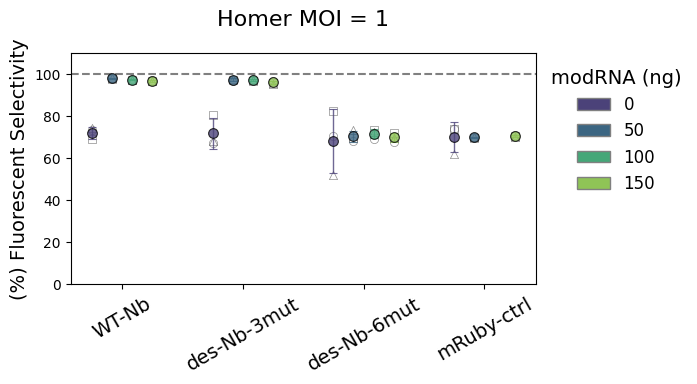

In [41]:
# General plotting params

x = 'cond'
y = 'mRuby_selectivity'
hue = 'conc'
hue_order = [0, 50, 100, 150]

order = ['wtNb(Homer)', 'desNb(Homer)-3mut', 'desNb(Homer)-6mut', 'mRuby-ctrl']

# Conditions

subset = summary_df[summary_df['moi'] == 1]

bio_means = (
    subset
    .groupby(['cond', 'moi', 'conc','biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'moi', 'conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers={'A': 's', 'B': 'o', 'C': '^'}


# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, conc in enumerate(hue_order):

            row = rep_data[
                (rep_data['cond'] == cond) &
                (rep_data['conc'] == conc)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, conc in enumerate(hue_order):

        row = summary[
            (summary['cond'] == cond) &
            (summary['conc'] == conc)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[conc],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

ax.yaxis.set_label_text('(%) Fluorescent Selectivity', fontsize=yaxis_fontsize)

ax.set_xlabel('')

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3mut': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'mRuby-ctrl': 'mRuby-ctrl'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)
# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p}'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='modRNA (ng)',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)

ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

plottitle = 'homer_mod_selectivity_MOI1.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## 1 biorep of MOI 0.1, 1, and 5

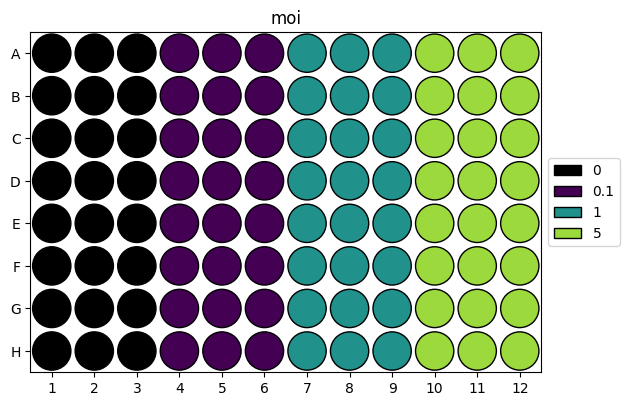

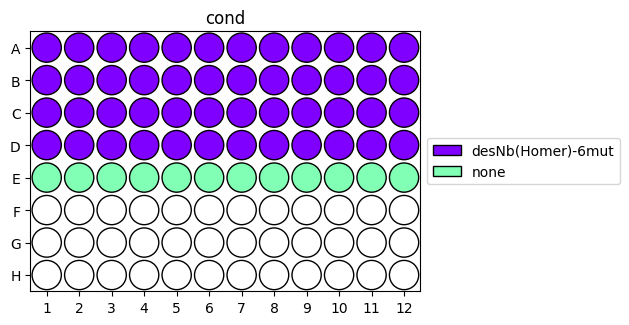

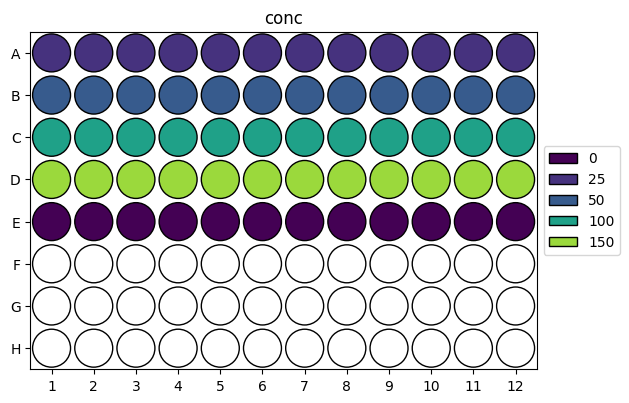

In [3]:
yaml_path_wt_3maj = rd.datadir/'data'/'attune'/'Maria'/'2026.06.18_homer_mod_select'/'wt_3maj'/'Single_cell_csvs'/'wells.yaml'
yaml_path_6mut = rd.datadir/'data'/'attune'/'Maria'/'2026.06.18_homer_mod_select'/'6mut_none'/'Single_cell_csvs'/'wells.yaml'
rd.plot.plot_well_metadata(yaml_path_6mut)

In [4]:
data_path_wt_3maj = rd.datadir/'data'/'attune'/'Maria'/'2026.06.18_homer_mod_select'/'wt_3maj'/'Single_cell_csvs'
data_path_6mut = rd.datadir/'data'/'attune'/'Maria'/'2026.06.18_homer_mod_select'/'6mut_none'/'Single_cell_csvs'

In [5]:
df_wt_3maj = rd.flow.load_csv_with_metadata(data_path_wt_3maj, yaml_path_wt_3maj)
df_6mut = rd.flow.load_csv_with_metadata(data_path_6mut, yaml_path_6mut)

In [6]:
df_2 = pd.concat([df_wt_3maj, df_6mut], ignore_index=True)

In [7]:
df_log_friendly_2 = df_2.loc[(df_2['GFP-A'] > 0) & (df_2['TagBFP-A'] > 0) & (df_2['mRuby2-A'] > 0)].copy()

In [8]:
cond_order = ['wtNb(Homer)', 'desNb(Homer)-3maj', 'desNb(Homer)-6mut', 'none']
df_log_friendly_2['cond'] = pd.Categorical(
    df_log_friendly_2['cond'], 
    categories=cond_order, 
    ordered=True
)

In [9]:
numSamples = 10**4
small_data_moi_0_2 = df_log_friendly_2[df_log_friendly_2.moi == 0].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_moi_1_2 = df_log_friendly_2[df_log_friendly_2.moi == 1].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_moi_01_2 = df_log_friendly_2[df_log_friendly_2.moi == 0.1].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_moi_5_2 = df_log_friendly_2[df_log_friendly_2.moi == 5].groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)
small_data_all_2 = df_log_friendly_2.groupby(['cond'], observed=True).sample(n=numSamples, random_state=1)

In [10]:
small_data_all_2 = small_data_all_2.sort_values('cond')

In [15]:
TagBFP_A_thresh_2 = small_data_moi_0_2['TagBFP-A'].quantile(0.999)
untransfected_2 = small_data_all_2[small_data_all_2['conc']==0]
mRuby2_A_thresh_2 = untransfected_2['mRuby2-A'].quantile(0.999)

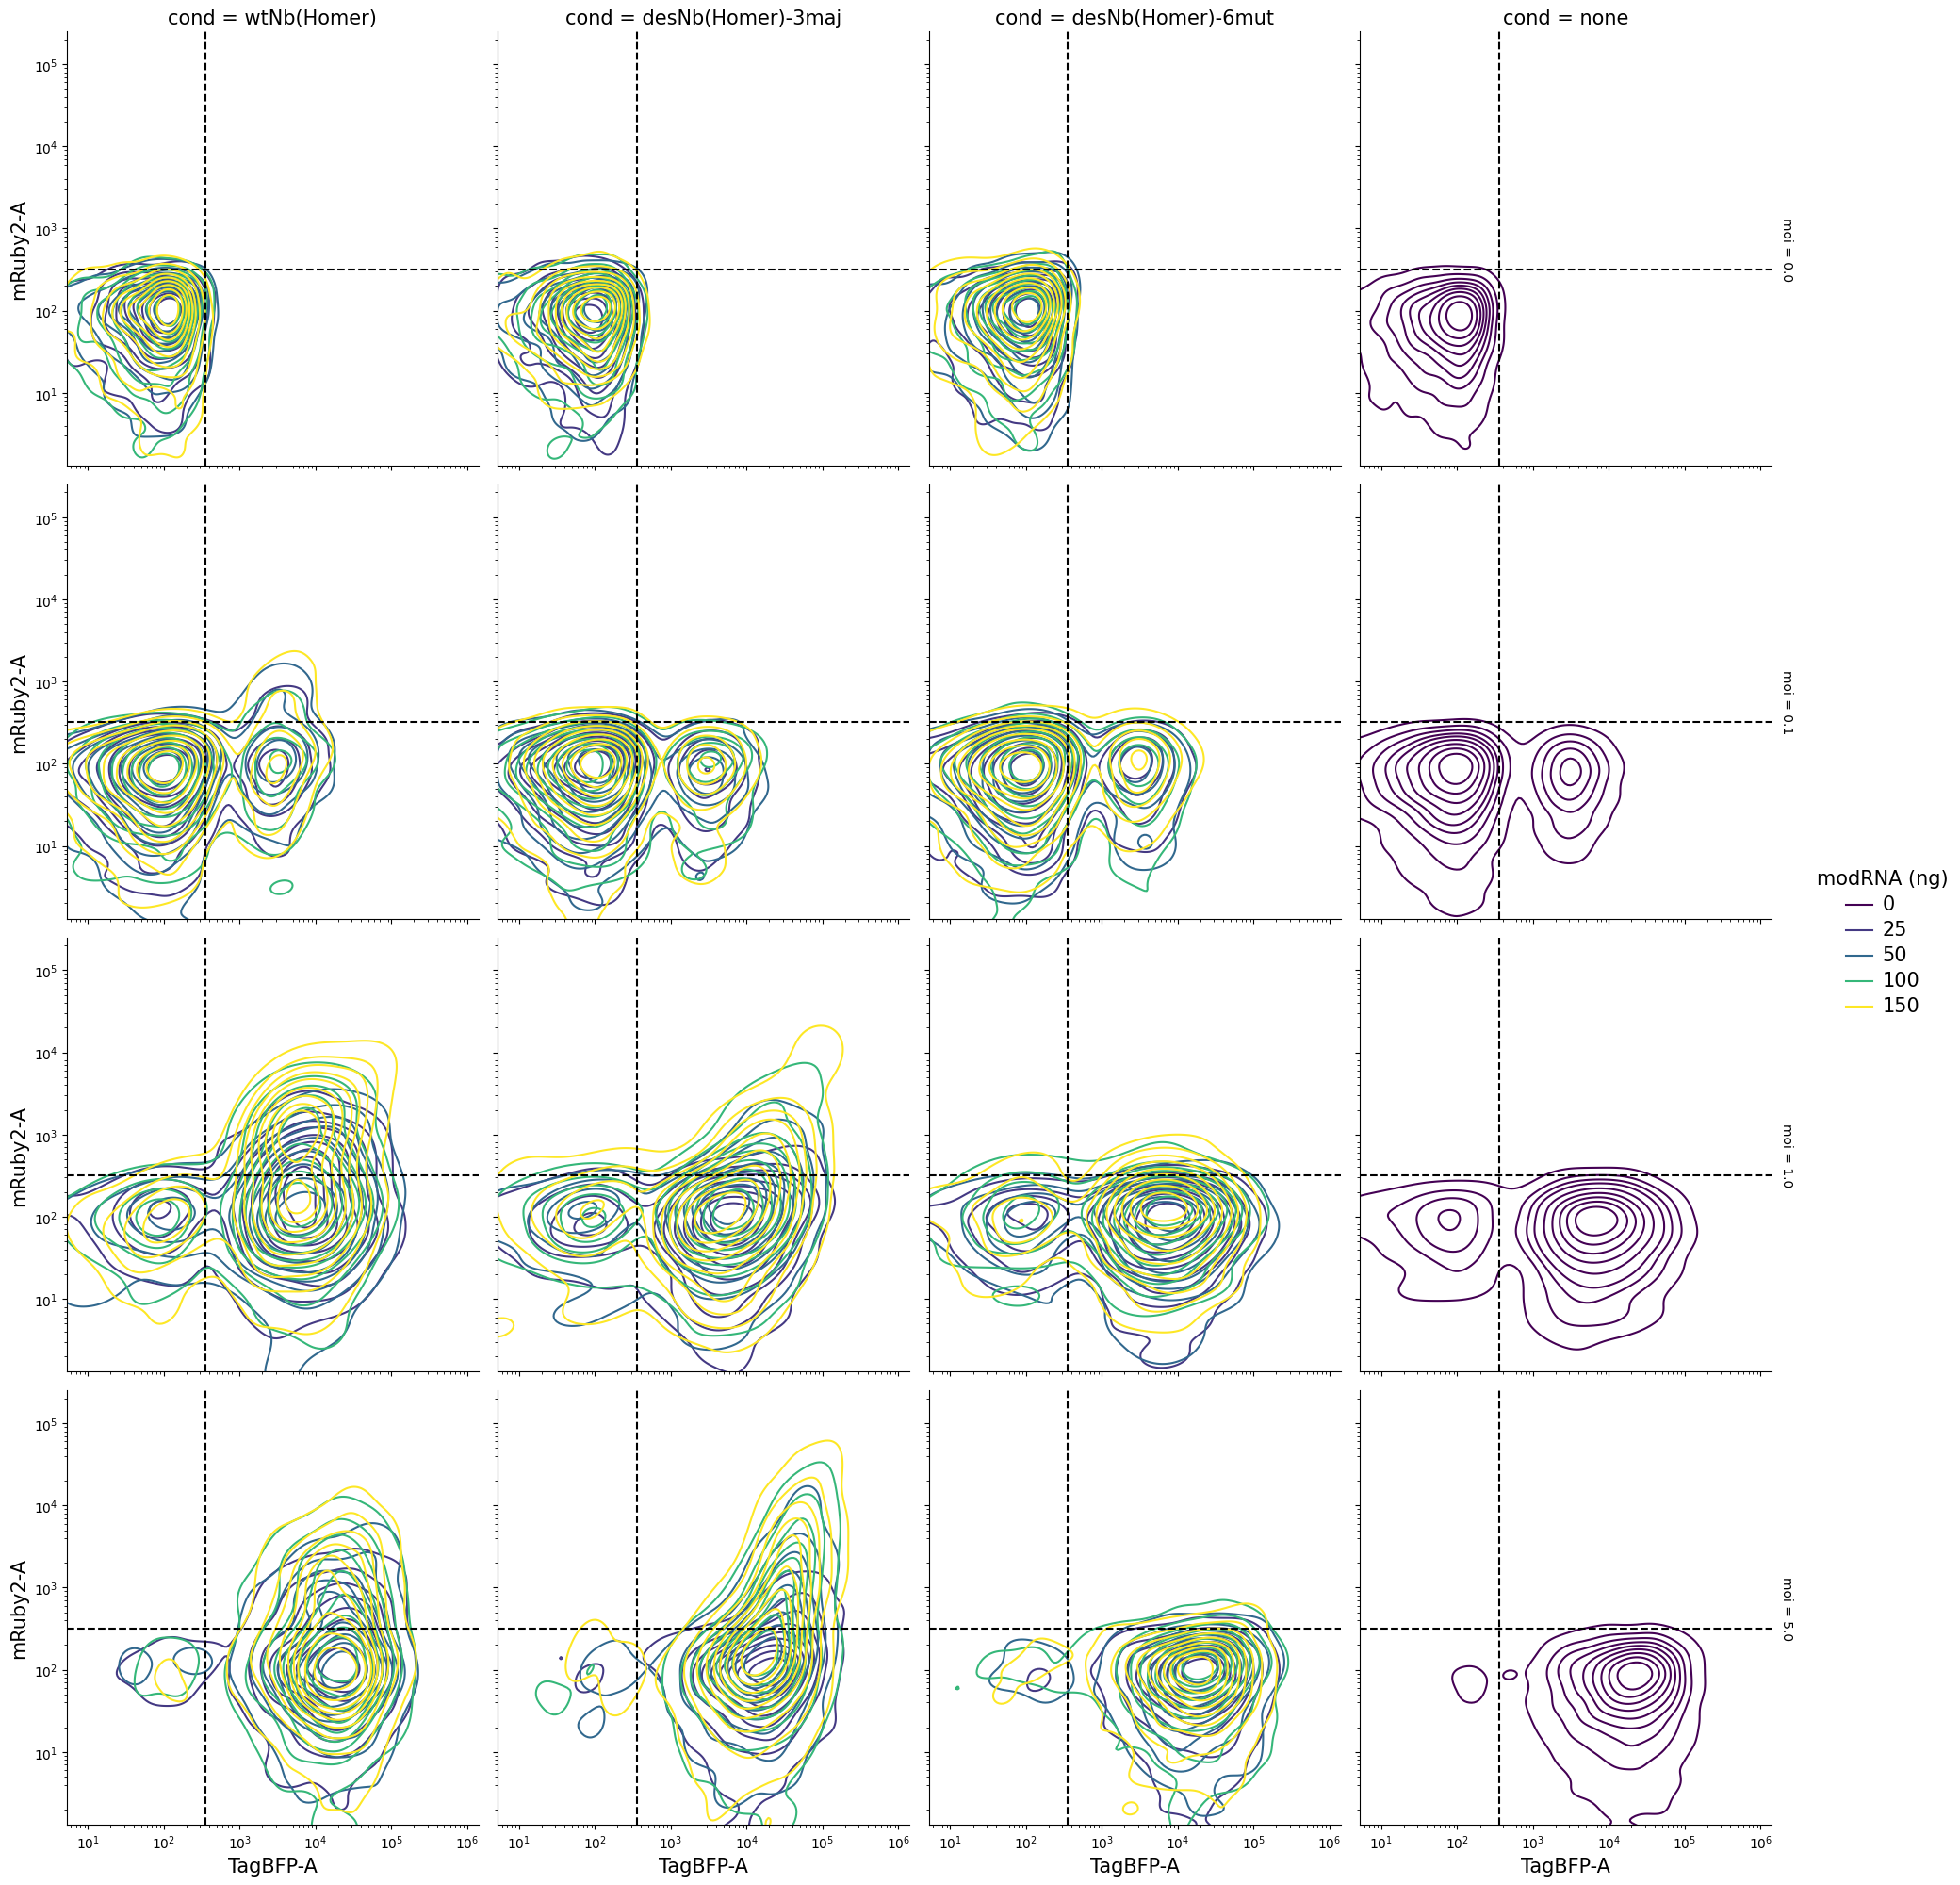

In [18]:
g = sns.displot(data = small_data_all_2, x = 'TagBFP-A', y = 'mRuby2-A', hue = 'conc', row = 'moi',col = 'cond', col_order=cond_order, log_scale=True, common_norm=False, kind='kde', facet_kws=dict(margin_titles=True), palette = palette)
ax_vlines = [ax.axvline(TagBFP_A_thresh_2, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_hlines = [ax.axhline(mRuby2_A_thresh_2, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_xfontsizes = [ax.set_xlabel(ax.get_xlabel(), fontsize=15) for ax in g.axes.flatten()]
ax_yfontsizes = [ax.set_ylabel(ax.get_ylabel(), fontsize=15) for ax in g.axes.flatten()]
ax_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes.flatten()]
ax_row_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes[:,0]]

# Change the legend title
g.legend.set_title("modRNA (ng)")

# Change font sizes
plt.setp(g.legend.get_texts(), fontsize=15)
g.legend.get_title().set_fontsize(15)

plottitle = 'homer_mod_contour_MOI0_01_1_5.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

In [26]:
# Cat mRuby2 and TagBFP
df_2.loc[:, 'TagBFP_cat'] = 'TagBFP-'
df_2.loc[(df_2['TagBFP-A'] > TagBFP_A_thresh_2), 'TagBFP_cat'] = 'TagBFP+'
df_2.loc[:, 'mRuby2_cat'] = 'mRuby2-'
df_2.loc[(df_2['mRuby2-A'] > mRuby2_A_thresh_2), 'mRuby2_cat'] = 'mRuby2+'

# Get only mRuby2+
mRuby2_df_2 = df_2.loc[df_2['mRuby2_cat'] == 'mRuby2+'] 

# Calculate mRuby2+ populations using these metrics
well_group = ['cond', 'moi', 'conc', 'well']
count_df_2 = mRuby2_df_2.groupby([*well_group])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if none rather than dropping row
mRuby_percent_df_2 = (count_df_2*100/count_df_2.groupby(well_group
                           ).transform('sum')).reset_index(name='percent')

mRuby_count = df_2.groupby([*well_group])['mRuby2-A'].apply(lambda x: sum(x > mRuby2_A_thresh_2)).reset_index(name = "mRuby_count")
BFP_count = df_2.groupby([*well_group])['TagBFP-A'].apply(lambda x: sum(x > TagBFP_A_thresh_2)).reset_index(name = "TagBFP_count")
double_count = df_2.groupby(well_group).apply(
    lambda g: ((g['mRuby2-A'] > mRuby2_A_thresh_2) &
               (g['TagBFP-A'] > TagBFP_A_thresh_2)).sum()
).reset_index(name='double_count')

summary_df_2 = (
    mRuby_count
    .merge(BFP_count)
    .merge(double_count)
)

summary_df_2['mRuby_selectivity'] = (
    summary_df_2['double_count'] /
    summary_df_2['mRuby_count'] * 100
)

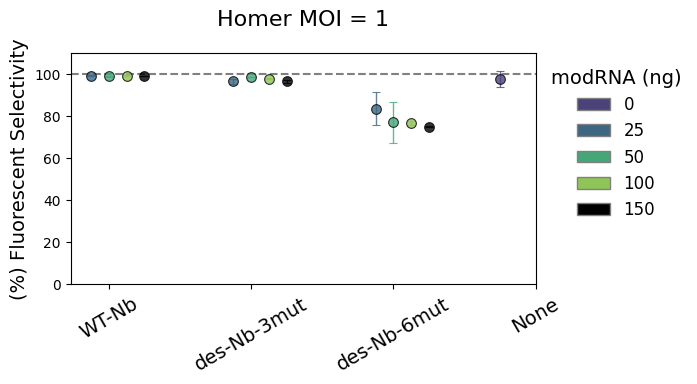

In [29]:
# General plotting params

x = 'cond'
y = 'mRuby_selectivity'
hue = 'conc'
hue_order = [0, 25, 50, 100, 150]

order = ['wtNb(Homer)', 'desNb(Homer)-3maj', 'desNb(Homer)-6mut', 'none']

# Conditions

subset = summary_df_2[summary_df_2['moi'] == 1]

bio_means = (
    subset
    .groupby(['cond', 'moi', 'conc','well'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'moi', 'conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers={'A': 's', 'B': 'o', 'C': '^'}


# Technical replicate dots (back layer)

# for rep, marker in markers.items():

#     rep_data = bio_means[bio_means.well == rep]

#     for i, cond in enumerate(order):
#         for j, conc in enumerate(hue_order):

#             row = rep_data[
#                 (rep_data['cond'] == cond) &
#                 (rep_data['conc'] == conc)
#             ]

#             if row.empty:
#                 continue

#             xloc = group_centers[i] + offsets[j]

#             ax.scatter(
#                 xloc,
#                 row[y].iloc[0],
#                 marker=marker,
#                 s=35,
#                 facecolor='white',
#                 edgecolor='black',
#                 linewidth=0.5,
#                 alpha=alpha_biorep,
#                 zorder=2
#             )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, conc in enumerate(hue_order):

        row = summary[
            (summary['cond'] == cond) &
            (summary['conc'] == conc)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[conc],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

ax.yaxis.set_label_text('(%) Fluorescent Selectivity', fontsize=yaxis_fontsize)

ax.set_xlabel('')

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 1',
    fontsize=title_fontsize,
    pad=20
)
# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p}'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='modRNA (ng)',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)

ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

plottitle = 'homer_mod_selectivity_MOI1_1_BR.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

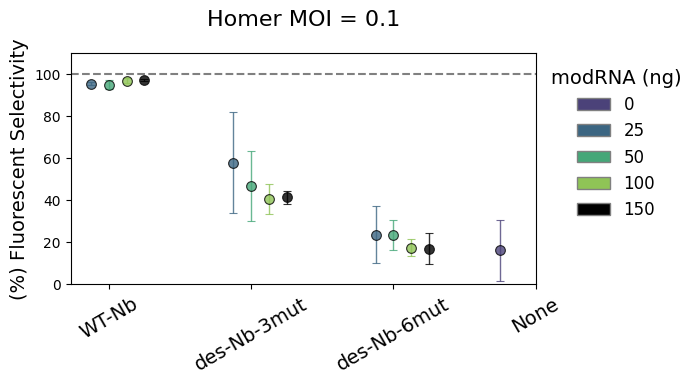

In [34]:
# General plotting params

x = 'cond'
y = 'mRuby_selectivity'
hue = 'conc'
hue_order = [0, 25, 50, 100, 150]

order = ['wtNb(Homer)', 'desNb(Homer)-3maj', 'desNb(Homer)-6mut', 'none']

# Conditions

subset = summary_df_2[summary_df_2['moi'] == 0.1]

bio_means = (
    subset
    .groupby(['cond', 'moi', 'conc','well'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'moi', 'conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

#markers={'A': 's', 'B': 'o', 'C': '^'}


# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.well == rep]

    for i, cond in enumerate(order):
        for j, conc in enumerate(hue_order):

            row = rep_data[
                (rep_data['cond'] == cond) &
                (rep_data['conc'] == conc)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, conc in enumerate(hue_order):

        row = summary[
            (summary['cond'] == cond) &
            (summary['conc'] == conc)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[conc],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

ax.yaxis.set_label_text('(%) Fluorescent Selectivity', fontsize=yaxis_fontsize)

ax.set_xlabel('')

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 0.1',
    fontsize=title_fontsize,
    pad=20
)
# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p}'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='modRNA (ng)',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)

ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

plottitle = 'homer_mod_selectivity_MOI1_01_BR.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

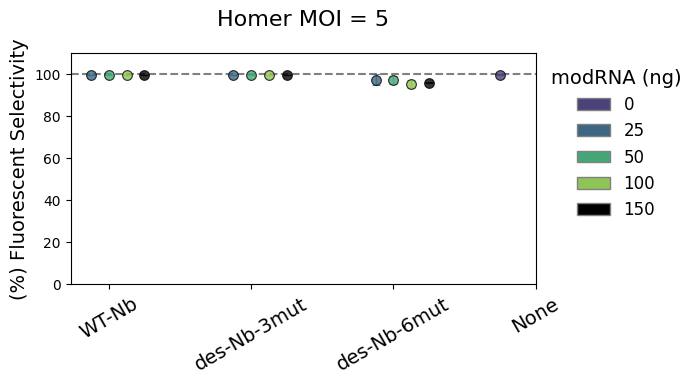

In [33]:
# General plotting params

x = 'cond'
y = 'mRuby_selectivity'
hue = 'conc'
hue_order = [0, 25, 50, 100, 150]

order = ['wtNb(Homer)', 'desNb(Homer)-3maj', 'desNb(Homer)-6mut', 'none']

# Conditions

subset = summary_df_2[summary_df_2['moi'] == 5]

bio_means = (
    subset
    .groupby(['cond', 'moi', 'conc','well'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'moi', 'conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

# markers={'A': 's', 'B': 'o', 'C': '^'}


# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.well == rep]

    for i, cond in enumerate(order):
        for j, conc in enumerate(hue_order):

            row = rep_data[
                (rep_data['cond'] == cond) &
                (rep_data['conc'] == conc)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, conc in enumerate(hue_order):

        row = summary[
            (summary['cond'] == cond) &
            (summary['conc'] == conc)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[conc],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

ax.yaxis.set_label_text('(%) Fluorescent Selectivity', fontsize=yaxis_fontsize)

ax.set_xlabel('')

ax.set_xticks(group_centers)

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)

ax.set_title(
    'Homer MOI = 5',
    fontsize=title_fontsize,
    pad=20
)
# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p}'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='modRNA (ng)',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)

ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

plottitle = 'homer_mod_selectivity_MOI1_5_BR.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')